In [1]:
import subprocess
import sys
import re
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")
import multiprocessing as mp
import pandas as pd
import numpy as np
import spacehub_calc
import matplotlib.animation as animation


In [2]:
title = "TwoBodyNewtonian"

cppFile = f"simulations/{title}.cpp"
execFile = cppFile[:-4]
makecmd = f"g++ -std=c++17 -O3 -pthread {cppFile} -o {execFile}"
simresultFile = f"simulation_results/{title}-output.txt"


#clean
result = subprocess.run(
f"rm {execFile}", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)

result = subprocess.run(
f"rm {simresultFile}", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    
print("Cleaned")

#make
result = subprocess.run(
makecmd, 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    raise OSError("Make error")
print("Made")

#run sim
result = subprocess.run(
f"./{execFile}", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    raise OSError("Runtime error")
print("Executed with exit code 0")
print(result.stdout)

#Rename output file
result = subprocess.run(
f"mv simulation_results/Result.txt {simresultFile}", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    raise OSError("Runtime error")
print("Executed with exit code 0")
print(result.stdout)

Cleaned
Made
Executed with exit code 0
Simulation complete
Executed with exit code 0



In [3]:
df = spacehub_calc.load_spacehub_data(simresultFile)
df

,time,id,mass,px,py,pz,vx,vy,vz,p,v
0,0.000000,0,1000.0,0.002141,-0.001748,0.002141,0.006810,0.016682,0.006810,0.003497,0.019263
1,0.000000,1,1.0,-2.141162,1.748252,-2.141162,-6.810447,-16.682120,-6.810447,3.496503,19.262853
2,0.023002,0,1000.0,0.002284,-0.001355,0.002284,0.005623,0.017515,0.005623,0.003503,0.019235
3,0.023002,1,1.0,-2.284293,1.354549,-2.284293,-5.623185,-17.514662,-5.623185,3.502969,19.235483
4,0.058723,0,1000.0,0.002451,-0.000712,0.002451,0.003680,0.018364,0.003680,0.003538,0.019087
...,...,...,...,...,...,...,...,...,...,...,...
49681,6283.166754,1,1.0,1.871150,3.833304,1.871150,-10.194265,4.568201,-10.194265,4.657963,15.123311
49682,6283.185144,0,1000.0,-0.001681,-0.003911,-0.001681,0.010525,-0.003846,0.010525,0.004576,0.015374
49683,6283.185144,1,1.0,1.680609,3.910750,1.680609,-10.525379,3.845852,-10.525379,4.576337,15.373932
49684,6283.185307,0,1000.0,-0.001679,-0.003911,-0.001679,0.010528,-0.003839,0.010528,0.004576,0.015376


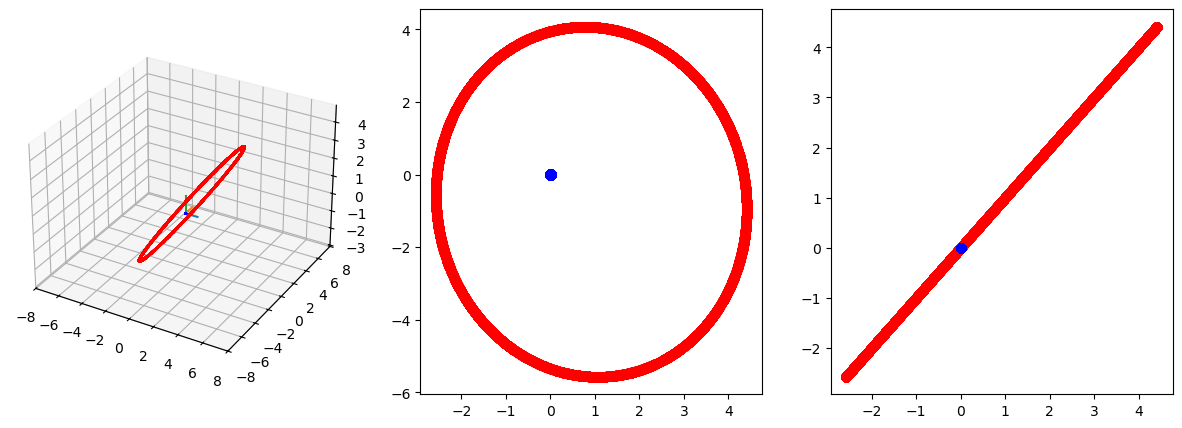

In [4]:
fig = plt.figure(figsize=(15, 5))
ax0 = fig.add_subplot(131, projection='3d')
ax1 = fig.add_subplot(132)
ax2 = fig.add_subplot(133)
ax0.plot([0,1],[0],[0])
ax0.plot([0],[0,1],[0])
ax0.plot([0],[0],[0,1])
ax0.scatter(df[df["id"]==1]["px"],df[df["id"]==1]["py"],df[df["id"]==1]["pz"], s=1, c='red')
ax0.scatter(df[df["id"]==0]["px"],df[df["id"]==0]["py"],df[df["id"]==0]["pz"], s=1, c='blue')
ax0.set_xlim(-8, 8)
ax0.set_ylim(-8, 8)
ax1.scatter(df[df["id"]==0]["px"], df[df["id"]==0]["py"], color='blue')
ax1.scatter(df[df["id"]==1]["px"], df[df["id"]==1]["py"], color='red')


ax2.scatter(df[df["id"]==1]["px"], df[df["id"]==1]["pz"], color='red')
ax2.scatter(df[df["id"]==0]["px"], df[df["id"]==0]["pz"], color='blue')

In [5]:
orbit = spacehub_calc.TwoBodyOrbit(simresultFile, 0, 1)

Text(0.5, 1.0, 'Argument of Periapsis (deg)')

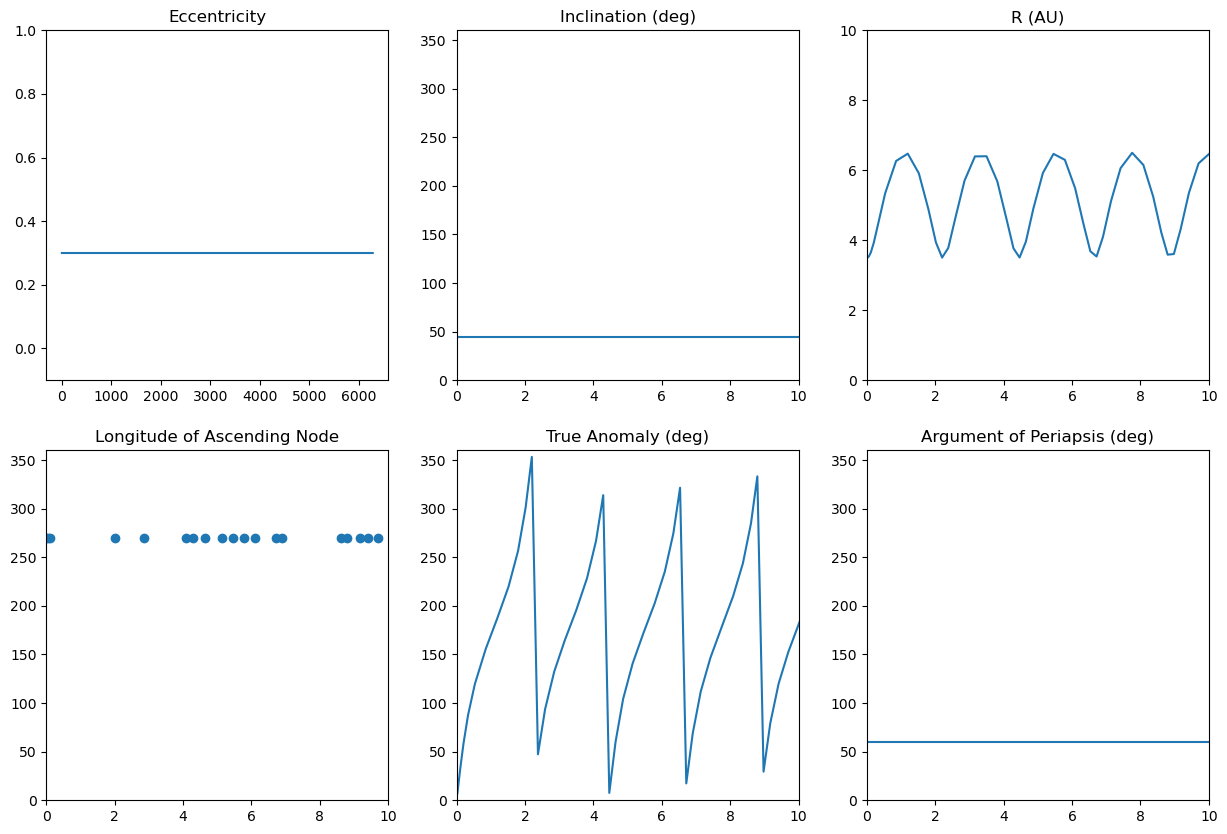

In [16]:
#e, a, i, Omega, f, omega

fig, axes = plt.subplots(2,3, figsize=(15, 10))
axs = axes.flatten()
axs[0].plot(orbit.time, orbit.eccentricity)
axs[0].set_ylim(-0.1, 1)
axs[0].set_title("Eccentricity")

axs[1].plot(orbit.time, orbit.inclination_deg)
axs[1].set_xlim(0,10)
major_ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
major_labels = ['0', 'π/2', 'π', '3π/2', '2π']
axs[1].set_ylim(0, 360)
axs[1].set_title("Inclination (deg)")

axs[2].plot(orbit.time, orbit.magR)
axs[2].set_xlim(0,10)
axs[2].set_title("R (AU)")
axs[2].set_ylim(0, 10)

axs[3].scatter(orbit.time, orbit.LongitudeAscendingNode_deg)
axs[3].set_title("Longitude of Ascending Node")
axs[3].set_xlim(0,10)
axs[3].set_ylim(0, 360)



axs[4].plot(orbit.time, orbit.true_anomaly_deg)
axs[4].set_xlim(0,10)
axs[4].set_ylim(0, 360)
axs[4].set_title("True Anomaly (deg)")

axs[5].plot(orbit.time, orbit.argument_of_periapsis_deg)
axs[5].set_xlim(0,10)
axs[5].set_ylim(0, 360)
axs[5].set_title("Argument of Periapsis (deg)")


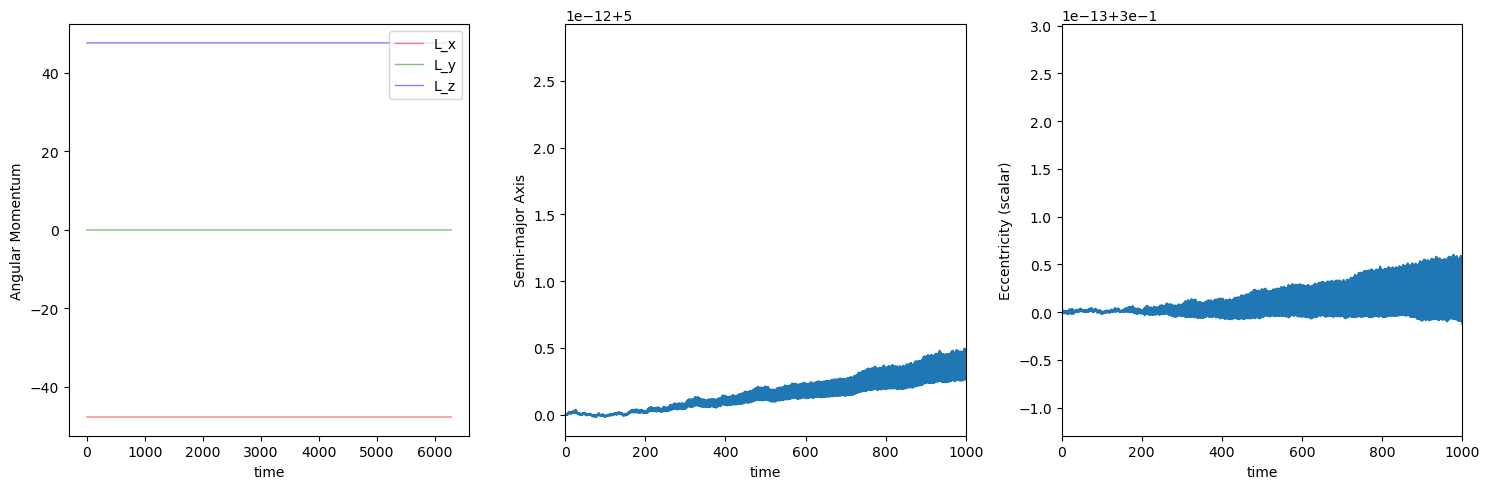

In [7]:
a12 = spacehub_calc.get_sma(df,0, 1)
L12x, L12y, L12z = spacehub_calc.get_L(df,0, 1)

t = df["time"].drop_duplicates()

df01 = pd.DataFrame(index=t)
df01["L_x"] = L12x
df01["L_z"] = L12z 
df01["L_y"] = L12y
df01["Semi-major Axis"] = a12
df01["Eccentricity (scalar)"] = spacehub_calc.get_scalar_e(df,0, 1)
f, axes = plt.subplots(1, 3, figsize=(15, 5))
axs = axes.flatten()

sns.lineplot(data=df01, x="time", y="L_x", ax=axs[0], color='red', label='L_x', lw=1, alpha=0.5)
sns.lineplot(data=df01, x="time", y="L_y", ax=axs[0], color='green', label='L_y', lw=1, alpha=0.5)
sns.lineplot(data=df01, x="time", y="L_z", ax=axs[0], color='blue', label='L_z', lw=1, alpha=0.5)

axs[0].set_ylabel("Angular Momentum")

sns.lineplot(data=df01, x="time", y="Semi-major Axis", ax=axs[1])
axs[1].set_xlim(0, 1000)
sns.lineplot(data=df01, x="time", y="Eccentricity (scalar)", ax=axs[2])
axs[2].set_xlim(0,1000)

f.tight_layout()